In [ ]:
import pandas as pd
import numpy as np
import multiprocessing as mp
import matplotlib.pyplot as plt
import json
import seaborn as sns
from catomatic.BinaryCatalogue import BinaryBuilder
import matplotlib
from collections import defaultdict
from matplotlib.collections import PolyCollection
from itertools import product
from statsmodels.stats.proportion import proportions_ztest
import numpy as np

from matplotlib.collections import PolyCollection

from protocols import utils, functions, graphs

plt.rcParams['figure.dpi'] = 200
plt.rcParams['font.family'] = 'Helvetica'  
plt.rcParams['font.size'] = 7 
plt.rcParams['figure.figsize'] = (6.69, 5.02)

%load_ext autoreload
%autoreload 2

In [ ]:
# the path to the CRyPTIC v3.1.0 data tables (including the DST_MEASUREMENTS_+.pkl which has DST for the validation samples appended)
cryptic_tables_path = 'data/cryptic-tables-v3.3.0/'

#read in genes relevant to each drug
with open('data/drug_to_genes.json', 'r') as f:
    drug_genes = json.load(f)

# whether to run the processes which take a long time
run_long_processes = False

# number of cores
n_cores = 10

In [3]:
drug_genes

{'AMI': {'genes': ['eis', 'rrs'], 'phylogenetic': []},
 'BDQ': {'genes': ['Rv0678', 'pepQ', 'atpE'], 'phylogenetic': []},
 'CAP': {'genes': ['rrs', 'tlyA'], 'phylogenetic': []},
 'CIP': {'genes': ['gyrA'], 'phylogenetic': []},
 'CFZ': {'genes': ['Rv0678', 'pepQ'], 'phylogenetic': []},
 'DLM': {'genes': ['ddn', 'dprE1'], 'phylogenetic': []},
 'EMB': {'genes': ['embA', 'embB'], 'phylogenetic': []},
 'ETH': {'genes': ['ethA', 'fabG1', 'inhA'], 'phylogenetic': []},
 'INH': {'genes': ['katG', 'inhA', 'ahpC', 'fabG1'], 'phylogenetic': []},
 'KAN': {'genes': ['eis', 'rrs'], 'phylogenetic': []},
 'LEV': {'genes': ['gyrA', 'gyrB'],
  'phylogenetic': ['gyrA@S95T', 'gyrA@E21Q', 'gyrA@G668D', 'gyrB@M291I']},
 'LZD': {'genes': ['rplC'], 'phylogenetic': []},
 'MXF': {'genes': ['gyrA', 'gyrB'],
  'phylogenetic': ['gyrA@S95T', 'gyrA@E21Q', 'gyrA@G668D', 'gyrB@M291I']},
 'PZA': {'genes': ['pncA'], 'phylogenetic': []},
 'RIF': {'genes': ['rpoB'], 'phylogenetic': []},
 'STM': {'genes': ['gid', 'rpsL', 'r

In [4]:
opt_cats_v1 = pd.read_csv('results/grid_search/opt_cats_v3.3.0_train.csv')
opt_cats_v1

,Unnamed: 0.1,Unnamed: 0,DRUG,BACKGROUND_RATE,p_value,SENSITIVITY,SPECIFICITY,DPR,SENSITIVITY2,SPECIFICITY2,Score,R,S,U,Total,catalogue
0,148,148.0,RIF,0.25,0.90,0.960991,0.984595,0.971067,0.937937,0.985072,0.970087,41,24,356,421,catomatic_v3.3.0_train
1,88,88.0,INH,0.25,0.90,0.944220,0.988071,0.956626,0.916105,0.988683,0.959857,64,26,642,732,catomatic_v3.3.0_train
2,154,154.0,STM,0.15,0.90,0.954290,0.931818,0.914743,0.896104,0.938396,0.939639,115,11,557,683,catomatic_v3.3.0_train
3,18,NaN,MXF,0.25,0.90,0.933853,0.938610,0.931845,0.907982,0.943277,0.934879,11,25,528,564,catomatic_v3.3.0_train
4,8,NaN,LEV,0.25,0.90,0.909487,0.969160,0.932272,0.876678,0.971469,0.931946,13,22,367,402,catomatic_v3.3.0_train
5,68,68.0,EMB,0.25,0.90,0.948433,0.916507,0.904180,0.861001,0.924563,0.930005,16,56,1091,1163,catomatic_v3.3.0_train
6,130,130.0,PZA,0.05,0.90,0.863924,0.972718,0.976187,0.855799,0.973436,0.919015,440,1,148,589,catomatic_v3.3.0_train
7,0,0.0,AMI,0.05,0.90,0.849802,0.982971,0.922734,0.826923,0.984358,0.904339,12,8,401,421,catomatic_v3.3.0_train
8,20,20.0,CAP,0.05,0.90,0.840217,0.976051,0.922950,0.808577,0.977981,0.897514,43,4,244,291,catomatic_v3.3.0_train
9,70,70.0,ETH,0.05,0.90,0.907003,0.868226,0.898733,0.820353,0.881747,0.893716,296,4,360,660,catomatic_v3.3.0_train


In [5]:
build_frs_values = np.arange(0.1, 1.0, 0.1)
test_frs_values = np.arange(0.1, 1.0, 0.1)

# Shared memory dictionaries for storing results
manager = mp.Manager()
sensitivity_matrix = manager.dict()
specificity_matrix = manager.dict()
dpr_matrix = manager.dict()
sensitivity2_matrix = manager.dict()
specificity2_matrix = manager.dict()

def process_drug_frs(args):

    drug, build_FRS = args

    mutations = functions.prep_mutations('data/mutations-v3.3.0/', 
                                    drug_genes[drug]['genes'], 
                                    version='v3.3.0', 
                                    mut_path=cryptic_tables_path+'MUTATIONS.parquet', 
                                    var_path=cryptic_tables_path+'VARIANTS.parquet', 
                                    train=True)
    
    test_mutations = functions.prep_mutations('data/mutations-v3.3.0/', 
                                    drug_genes[drug]['genes'], 
                                    version='v3.3.0', 
                                    mut_path=cryptic_tables_path+'MUTATIONS.parquet', 
                                    var_path=cryptic_tables_path+'VARIANTS.parquet', 
                                    train=False)
    
    phenotypes = functions.prep_phenotypes(
        drug,
        cryptic_tables_path+"DST_MEASUREMENTS.csv.gz",
        cryptic_tables_path+"GENOMES.parquet",
        cryptic_tables_path+"WGS_SAMPLES.parquet",
        'v3.3.0',
        validation=False
    )
    
    background, p = opt_cats_v1.loc[opt_cats_v1.DRUG == drug, ['BACKGROUND_RATE', 'p_value']].iloc[0]
    sens_results, spec_results, cov_results, sens2_results, spec2_results = {}, {}, {}, {}, {}
    

    catfile = f"./catalogues/cryptic-v3.3.0/frs/{drug.lower()}/bg_{background}_p_{p}_FRS_{np.round(build_FRS,1)}.csv"
    catalogue = BinaryBuilder(samples=phenotypes, mutations=mutations, FRS=build_FRS, seed=drug_genes[drug]['phylogenetic']).build(
        test='Binomial', background=background, strict_unlock=True, p=p
    )
    print(f'{drug}-{background}-{p}-{np.round(build_FRS, 1)}')
    catalogue.to_piezo(
        genbank_ref='NC00962.3',
        catalogue_name=f'{drug}-{background}-{p}-{np.round(build_FRS, 1)}',
        version='0.0',
        drug=drug,
        wildcards=f"./data/wildcards/{drug.lower()}_wildcards.json",
        json_dumps=True,
        outfile=catfile
    )

    sens_results[build_FRS], spec_results[build_FRS], cov_results[build_FRS] = {}, {}, {}
    sens2_results[build_FRS], spec2_results[build_FRS] = {}, {} 

    for test_FRS in test_frs_values:
        all_data = pd.merge(
            phenotypes,
            test_mutations[test_mutations.FRS >= test_FRS],
            on=['UNIQUEID'],
            how='left'
        )
        print (drug, build_FRS, test_FRS)
        _, cov, sens, spec, sens2, spec2 = utils.piezo_predict(iso_df=all_data, drug=drug, catalogue_file=catfile)
        sens_results[build_FRS][test_FRS] = sens * 100
        spec_results[build_FRS][test_FRS] = spec * 100
        cov_results[build_FRS][test_FRS] = cov * 100
        sens2_results[build_FRS][test_FRS] = sens2 * 100
        spec2_results[build_FRS][test_FRS] = spec2 * 100


    sensitivity_matrix[(drug, build_FRS)] = sens_results[build_FRS]
    specificity_matrix[(drug, build_FRS)] = spec_results[build_FRS]
    dpr_matrix[(drug, build_FRS)] = cov_results[build_FRS]
    sensitivity2_matrix[(drug, build_FRS)] = sens2_results[build_FRS]
    specificity2_matrix[(drug, build_FRS)] = spec2_results[build_FRS]


def convert_to_dataframe(matrix, metric):
    data = []
    for (drug, build_FRS), test_results in matrix.items():
        for test_FRS, value in test_results.items():
            data.append([drug, build_FRS, test_FRS, value])
    df = pd.DataFrame(data, columns=['Drug', 'Build_FRS', 'Test_FRS', metric])
    df.set_index(['Drug', 'Build_FRS', 'Test_FRS'], inplace=True)
    return df



In [6]:
# Parallel execution
if run_long_processes:

    mp.set_start_method('fork', force=True)
    #opt_cats_v1
    all_tasks = list(product(['MXF', 'LEV'], build_frs_values))
    with mp.Pool(mp.cpu_count()) as pool:
        pool.map(process_drug_frs, all_tasks)

    sensitivity_df = convert_to_dataframe(sensitivity_matrix, 'Sensitivity')
    specificity_df = convert_to_dataframe(specificity_matrix, 'Specificity')
    dpr_df = convert_to_dataframe(dpr_matrix, 'DPR')
    sensitivity2_df = convert_to_dataframe(sensitivity2_matrix, 'Sensitivity2')
    specificity2_df = convert_to_dataframe(specificity2_matrix, 'Specificity2')

    perf_df = sensitivity_df.join(specificity_df).join(dpr_df).join(sensitivity2_df).join(specificity2_df)

    #perf_df.to_csv('results/frs/v3.3.0_train_perf.csv', index=True)

else:
    
    perf_df = pd.read_csv('results/frs/v3.3.0_train_perf.csv')
perf_df.reset_index(inplace=True)
catalogued_R, catalogued_S, catalogued_RS = [], [], []
for i in perf_df.index:
    drug = perf_df['Drug'][i]
    background = opt_cats_v1[opt_cats_v1.DRUG==drug].BACKGROUND_RATE.values[0]
    p = opt_cats_v1[opt_cats_v1.DRUG==drug].p_value.values[0]
    build_FRS = perf_df['Build_FRS'][i]
    catfile = f"./catalogues/cryptic-v3.3.0/frs/{drug.lower()}/bg_{background}_p_{p}_FRS_{np.round(build_FRS,1)}.csv"
    cat = pd.read_csv(catfile)
    catalogued_R.append(cat[(cat.PREDICTION == 'R') & (~cat.MUTATION.str.contains(r'\*'))].MUTATION.nunique())
    catalogued_S.append(cat[(cat.PREDICTION == 'S') & (~cat.MUTATION.str.contains(r'\*'))].MUTATION.nunique())
    catalogued_RS.append(cat[(cat.PREDICTION.isin(['R', 'S'])) & (~cat.MUTATION.str.contains(r'\*'))].MUTATION.nunique())
perf_df['catalogued_R'] = catalogued_R
perf_df['catalogued_S'] = catalogued_S
perf_df['catalogued_RS'] = catalogued_RS

perf_df



LEV-0.25-0.9-0.1
OUTFILE ./catalogues/cryptic-v3.3.0/frs/lev/bg_0.25_p_0.9_FRS_0.1.csv
LEV 0.1 0.1
MXF-0.25-0.9-0.9
OUTFILE ./catalogues/cryptic-v3.3.0/frs/mxf/bg_0.25_p_0.9_FRS_0.9.csv
MXF 0.9 0.1
MXF-0.25-0.9-0.7
OUTFILE ./catalogues/cryptic-v3.3.0/frs/mxf/bg_0.25_p_0.9_FRS_0.7.csv
MXF 0.7000000000000001 0.1
MXF-0.25-0.9-0.4
OUTFILE ./catalogues/cryptic-v3.3.0/frs/mxf/bg_0.25_p_0.9_FRS_0.4.csv
MXF-0.25-0.9-0.2
OUTFILE ./catalogues/cryptic-v3.3.0/frs/mxf/bg_0.25_p_0.9_FRS_0.2.csv
MXF 0.4 0.1
MXF 0.2 0.1
MXF-0.25-0.9-0.8
OUTFILE MXF-0.25-0.9-0.5./catalogues/cryptic-v3.3.0/frs/mxf/bg_0.25_p_0.9_FRS_0.8.csv

OUTFILE ./catalogues/cryptic-v3.3.0/frs/mxf/bg_0.25_p_0.9_FRS_0.5.csv
MXF 0.8 0.1
MXF MXF-0.25-0.9-0.60.5
 0.1
OUTFILE ./catalogues/cryptic-v3.3.0/frs/mxf/bg_0.25_p_0.9_FRS_0.6.csv
MXF 0.6000000000000001 0.1
MXF-0.25-0.9-0.1
OUTFILE ./catalogues/cryptic-v3.3.0/frs/mxf/bg_0.25_p_0.9_FRS_0.1.csv
MXF-0.25-0.9-0.3
OUTFILEMXF  ./catalogues/cryptic-v3.3.0/frs/mxf/bg_0.25_p_0.9_FRS_0.3.csv0

,Drug,Build_FRS,Test_FRS,Sensitivity,Specificity,DPR,Sensitivity2,Specificity2,catalogued_R,catalogued_S,catalogued_RS
0,LEV,0.1,0.1,90.948651,96.915984,93.227153,87.667785,97.146919,13,20,33
1,LEV,0.1,0.2,90.575916,96.961637,93.296737,87.080537,97.184834,13,20,33
2,LEV,0.1,0.3,89.811981,96.995094,93.327664,86.157718,97.213270,13,20,33
3,LEV,0.1,0.4,89.137100,97.057020,93.312200,85.360738,97.270142,13,20,33
4,LEV,0.1,0.5,88.402626,97.079248,93.374053,84.731544,97.289100,13,20,33
...,...,...,...,...,...,...,...,...,...,...,...
157,LEV,0.9,0.5,88.541667,96.888073,93.590537,85.570470,97.109005,16,19,35
158,LEV,0.9,0.6,87.386216,96.960424,93.636926,84.563758,97.175355,16,19,35
159,LEV,0.9,0.7,85.899654,97.003364,93.729705,83.305369,97.213270,16,19,35
160,LEV,0.9,0.8,84.641933,97.056427,93.830215,82.298658,97.260664,16,19,35


In [7]:
drug_df = perf_df[perf_df["Drug"] == 'CAP'].copy()

# Round Build_FRS to 2 decimals to avoid float noise
drug_df["Build_FRS"] = drug_df["Build_FRS"].round(2)

# Drop duplicates AFTER rounding
drug_df = (
    drug_df
    .drop_duplicates(subset=["Build_FRS"])
    .sort_values("Build_FRS")
)
drug_df

,Drug,Build_FRS,Test_FRS,Sensitivity,Specificity,DPR,Sensitivity2,Specificity2,catalogued_R,catalogued_S,catalogued_RS


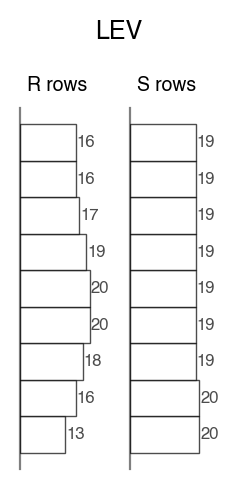

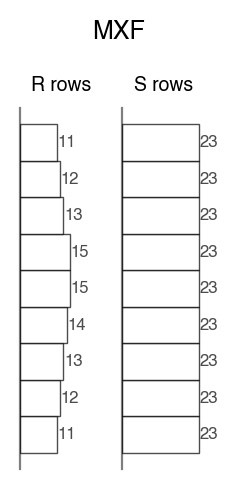

In [8]:

graphs.plot_catalogue_bar_charts(perf_df)

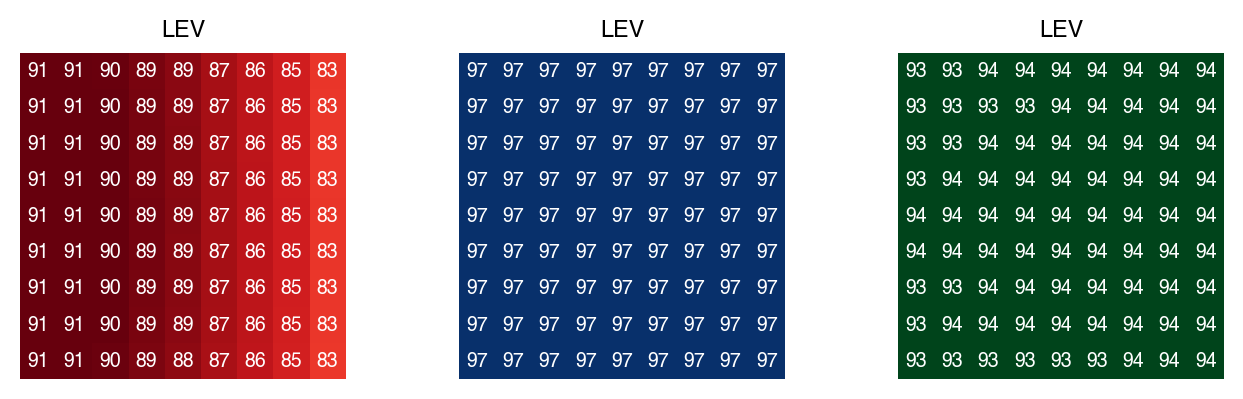

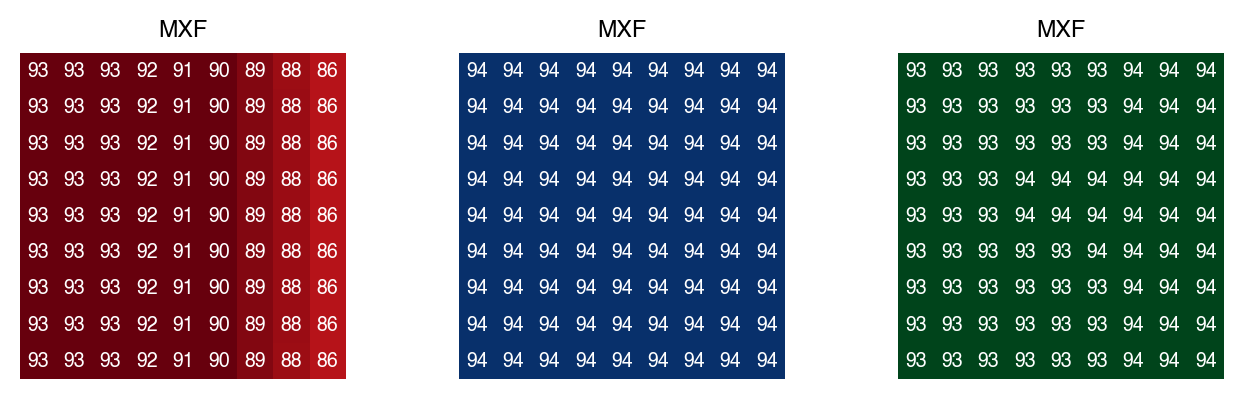

In [9]:

perf_df = perf_df.drop_duplicates(['Drug', 'Build_FRS', 'Test_FRS'], keep='first')
utils.plot_perf_heatmaps(perf_df, draw_axes=False)

### Confidence limit waterfall plots

In [10]:
varying_mutations = {}
for drug in perf_df.Drug.unique():
    muts = {}
    df = perf_df[perf_df.Drug == drug].reset_index()
    
    for i in df.drop_duplicates(['Build_FRS'], keep='first').index:
        background = opt_cats_v1[opt_cats_v1.DRUG == drug].BACKGROUND_RATE.values[0]
        p = opt_cats_v1[opt_cats_v1.DRUG == drug].p_value.values[0]
        build_FRS = df['Build_FRS'][i]
        catfile = f"./catalogues/cryptic-v3.3.0/frs/{drug.lower()}/bg_{background}_p_{p}_FRS_{np.round(build_FRS,1)}.csv"
        cat = pd.read_csv(catfile)
        cat = cat[(cat.PREDICTION.isin(['R', 'S'])) & (~cat.MUTATION.str.contains(r'\*'))]
        muts[float(build_FRS)] = set(cat.MUTATION.values)  # Make them sets!

    all_muts_sets = list(muts.values())
    
    common_muts = set.intersection(*all_muts_sets)
    
    varying_muts = set.union(*all_muts_sets) - common_muts
    
    print(f"Drug: {drug}")
    print(f"Varying Mutations (changing across FRS):")
    print(varying_muts)
    print("-" * 40)
    varying_mutations[drug] = varying_muts





Drug: LEV
Varying Mutations (changing across FRS):
{'gyrB@N499K', 'gyrA@D94R', 'gyrA@L105R', 'gyrB@E501V', 'gyrB@S447F', 'gyrA@D94C', 'gyrA@D94S', 'gyrB@E501D', 'gyrB@R575H'}
----------------------------------------
Drug: MXF
Varying Mutations (changing across FRS):
{'gyrA@D94R', 'gyrA@L105R', 'gyrA@D94C', 'gyrA@D94S', 'gyrB@N499K'}
----------------------------------------


In [11]:
build_frs_values

array([0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9])

In [12]:
import ast
frs_prop_data = defaultdict(lambda: defaultdict(lambda: {'count': [], 'frs': [], 'y': [], 'error': []}))

to_float = lambda x: float(x) if isinstance(x, np.float64) else x

for drug, mutations in varying_mutations.items():  # <<-- use your new varying mutation dictionary
    background, p = opt_cats_v1.loc[opt_cats_v1.DRUG == drug, ['BACKGROUND_RATE', 'p_value']].iloc[0]
    print (drug)
    for frs in build_frs_values:
        # Load the catalogue
        catalogue = utils.load_catomatic_catalogue(
            drug, background, p, np.round(frs, 1), dir='catalogues/cryptic-v3.3.0/frs/'
        )

        catalogue = catalogue[catalogue.EVIDENCE!={'seeded': 'True'}	]
        
        for field in ['PROPORTION', 'CONFIDENCE', 'CONTINGENCY']:
            catalogue[field] = catalogue['EVIDENCE'].apply(lambda x: utils.extract_value(x, field.lower()))

        catalogue['MUT_COUNT'] = catalogue['CONTINGENCY'].apply(lambda c: c[0][0] + c[0][1])
        # Filter only to relevant mutations (varying ones for this drug)
        catalogue_muts = catalogue[catalogue.MUTATION.isin(mutations)]

        def extract_errors(df, prop_col, conf_col):
            def clean_ci(ci):
                if isinstance(ci, list) and len(ci) == 2:
                    return [max(0, np.round(float(ci[0]), 3)), min(1, np.round(float(ci[1]), 3))] 
                return [np.nan, np.nan]

            prop = df[prop_col]
            err = df[conf_col].apply(clean_ci)

            if len(prop) > 1:
                return (np.array(prop).flatten(), np.vstack(err))
            elif len(prop) == 1:
                return (np.array(prop).flatten(), np.stack(err.values).T)
            else:
                return (np.array(prop).flatten(), err.to_numpy())

        prop, error = extract_errors(catalogue_muts, 'PROPORTION', 'CONFIDENCE')

        # Save the information
        for i, mutation in enumerate(catalogue_muts.MUTATION.tolist()):
            mut_count = catalogue_muts.iloc[i]['MUT_COUNT']  # Get count per mutation for current FRS
            frs_prop_data[drug][mutation]['frs'].append(to_float(frs))
            frs_prop_data[drug][mutation]['y'].append(prop[i])
            frs_prop_data[drug][mutation]['count'].append(mut_count)  # ✅ Store count per FRS

            frs_prop_data[drug][mutation]['error'].append(error[i] if prop.shape[0] > 1 else error)
            frs_prop_data[drug][mutation]['background'] = background

# Make final dict cleaner
frs_prop_data = {drug: dict(mutations) for drug, mutations in frs_prop_data.items()}


LEV
MXF


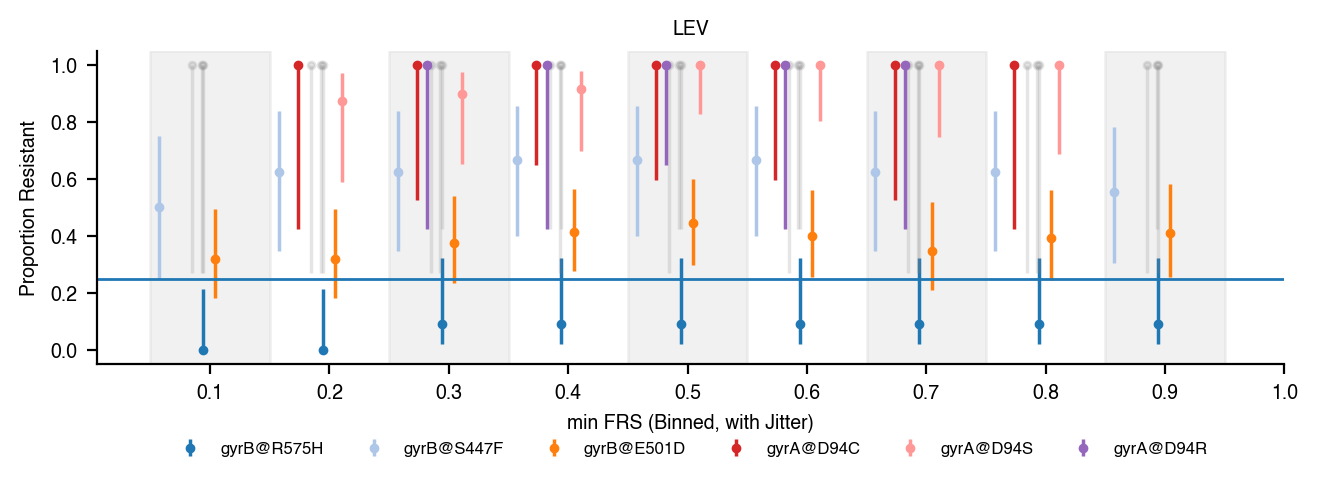

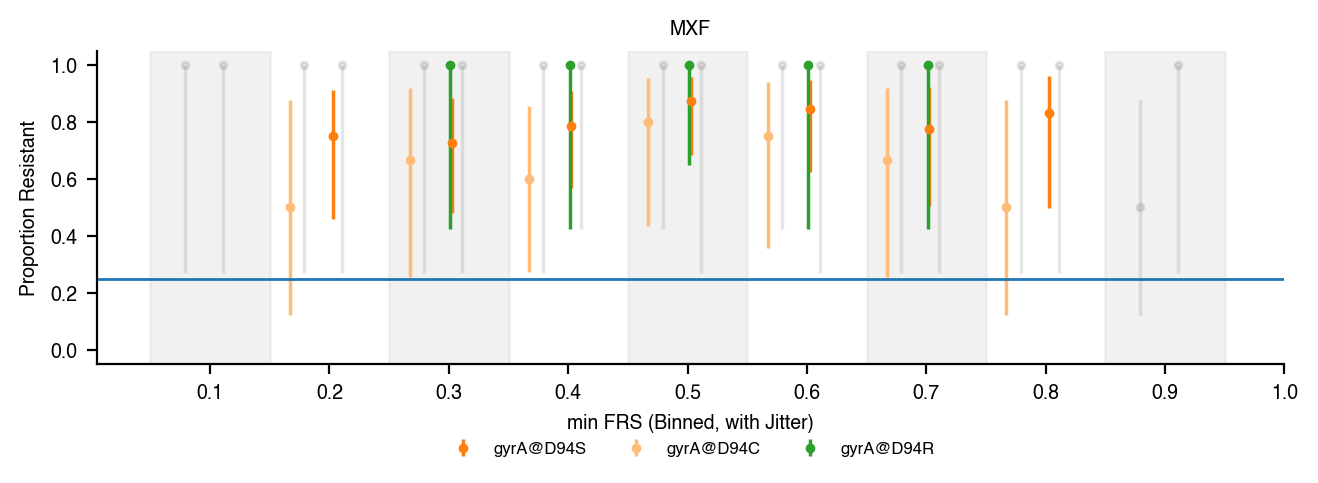

In [177]:
color_map = {}
for drug, mutations_dict in frs_prop_data.items():
    unique_mutations = list(mutations_dict.keys())
    color_map[drug] = dict(zip(unique_mutations, sns.color_palette("tab20", len(unique_mutations))))

graphs.plot_mutation_error_bars(frs_prop_data, color_map=color_map, min_err=1, figpath='figs/frs/')

### FRS vs essential/non-essential

In [63]:
phylogenetics = pd.read_csv('/Users/dylanadlard/Downloads/13073_2020_726_MOESM3_ESM (4).csv')
phylogenetics['MUTATION'] = phylogenetics['GeneName'] + '@' + phylogenetics['group_subst'].str.split(' ').str[0]
phylogenetics

,# group_id,ref,pos,gene,GeneName,annotation,category,PureSNP,group_allel,number_group_strains,...,pheno-S that are geno-R,pheno-S minus geno-R,pheno-R,pheno-R that are geno-R,pheno-R minus geno-R,true S + unexplained R,(true S)/(true S+unexplained R),ratio >0.9 = neutral,comment,MUTATION
0,group_311,G,5072,-,gyrB_upstream,-,-,1.0,T,2.0,...,NaN,NaN,NaN,NaN,NaN,NaN,no data,NaN,NaN,gyrB_upstream@5072
1,group_290,C,5075,-,gyrB_upstream,-,-,1.0,T,11.0,...,NaN,NaN,NaN,NaN,NaN,NaN,no data,NaN,NaN,gyrB_upstream@5075
2,group_329,A,5082,-,gyrB_upstream,-,-,0.0,GAP,2.0,...,NaN,NaN,NaN,NaN,NaN,NaN,no data,NaN,NaN,gyrB_upstream@5082_GAP
3,group_330,C,5671,Rv0005,gyrB,DNA gyrase (subunit B) GyrB (DNA topoisomerase...,essential,1.0,T,3.0,...,NaN,NaN,NaN,NaN,NaN,NaN,no data,NaN,NaN,gyrB@Y144Y
4,group_327,G,5752,Rv0005,gyrB,DNA gyrase (subunit B) GyrB (DNA topoisomerase...,essential,1.0,A,8.0,...,NaN,NaN,NaN,NaN,NaN,NaN,no data,NaN,NaN,gyrB@V171V
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
543,unique strain,C,737857,Rv0643c,mmaA3,Methoxy mycolic acid synthase 3 MmaA3 (methyl ...,essential,1.0,A,1.0,...,NaN,NaN,NaN,NaN,NaN,NaN,no data,NaN,NaN,mmaA3@G98D
544,group_302,wt,NaN,Rv1979c,Rv1979c,Possible conserved permease,nonessential,0.0,deleted,18.0,...,NaN,NaN,NaN,NaN,NaN,NaN,no data,NaN,convergent evolution by (partial) deletion of ...,Rv1979c@uncovered
545,unique strain,wt,NaN,Rv1979c,Rv1979c,Possible conserved permease,nonessential,0.0,deleted,2.0,...,NaN,NaN,NaN,NaN,NaN,NaN,no data,NaN,convergent evolution by (partial) deletion of ...,Rv1979c@partially
546,unique strain,wt,NaN,Rv1979c,Rv1979c,Possible conserved permease,nonessential,0.0,deleted,1.0,...,NaN,NaN,NaN,NaN,NaN,NaN,no data,NaN,convergent evolution by (partial) deletion of ...,Rv1979c@uncovered


In [204]:
essential = {'essential':["rpoB", "gyrA", "gyrB", "rplC", "dprE1", "atpE",  "rpsL", 'rrs', "embA", "embB",], 'non_essential':["eis", "tlyA", "pepQ", "inhA", "ethA", "ahpC", "katG", "ddn", "pncA", "Rv0678", "gid", "fabG1"]}
for type, genes in essential.items():
    mutations = functions.prep_mutations('data/mutations-v3.3.0/', 
                                        genes, 
                                        version='v3.3.0', 
                                        mut_path=cryptic_tables_path+'MUTATIONS.parquet', 
                                        var_path=cryptic_tables_path+'VARIANTS.parquet', 
                                        train=True)
    #mutations = mutations[~mutations.MUTATION.isin([v for d in drug_genes.values() for v in d['phylogenetic']])]
    catalogue = pd.read_csv('catalogues/catomatic_v3.3.0.csv')
    #mutations = mutations[mutations.MUTATION.isin(catalogue[catalogue.PREDICTION=='R'].MUTATION.values)]
    mutations = mutations[~mutations.MUTATION.isin(phylogenetics.MUTATION.values)]
    mutations['GENE'] = [i.split('@')[0] for i in mutations.MUTATION]
    #mutations = mutations[mutations.FRS<=0.9]
    if type=='essential':
        essential_frs = mutations.FRS.tolist()
        essential_gene_list = mutations.GENE.tolist()
    elif type=='non_essential':
        non_essential_frs = mutations.FRS.tolist()
        non_essential_gene_list = mutations.GENE.tolist()
    


0 Essential
1 Non-Essential


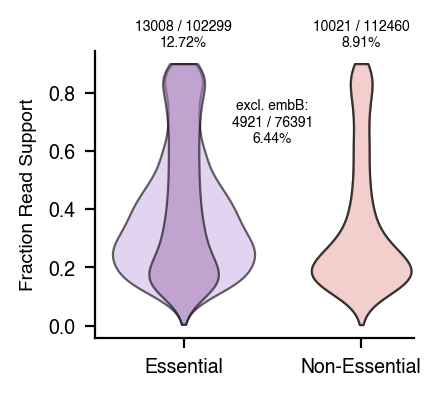

In [ ]:


# Create base dataframe
data = pd.DataFrame({
    "Read Support": essential_frs + non_essential_frs,
    "Gene Category": ["Essential"] * len(essential_frs) + ["Non-Essential"] * len(non_essential_frs),
    "Gene": essential_gene_list + non_essential_gene_list# This assumes you have these lists
})

order = ["Essential", "Non-Essential"]

# Define outlier gene to remove
outlier_gene = "embB"

# First dataset: all data < 0.9 FRS
plot_data = data[data["Read Support"] < 0.9].copy()

# Second dataset: outlier gene removed
plot_data_no_outlier = plot_data[plot_data["Gene"] != outlier_gene]

# Count totals for scaling
total_counts = data["Gene Category"].value_counts()
shown_counts = plot_data["Gene Category"].value_counts()
scaling_factors = (shown_counts / total_counts).to_dict()

fig, ax = plt.subplots(figsize=(2.2, 2))

# === Plot full violins first ===
sns.violinplot(
    x="Gene Category",
    y="Read Support",
    data=plot_data,
    inner=None,
    cut=0,
    bw=0.2,
    scale="area",
    palette={"Essential": "#CFAFEF", "Non-Essential": "#FFD1DC"},
    ax=ax,
    order=order
)

# Save number of violins before inset
n_base_violins = len(ax.findobj(match=PolyCollection))

# === Plot second set (inset violins) ===
sns.violinplot(
    x="Gene Category",
    y="Read Support",
    data=plot_data_no_outlier,
    inner=None,
    cut=0,
    bw=0.2,
    scale="area",
    palette={"Essential": "#AF7AC5", "Non-Essential": "#F5B7B1"},
    ax=ax,
    order=order
)

# === Scale both sets ===
category_positions = dict(zip(order, range(len(order))))
max_scale = max(scaling_factors.values())

# Process all violins
all_artists = ax.findobj(match=PolyCollection)

# Get full Essential stats (with embB)
essential_total = data[data["Gene Category"] == "Essential"]
essential_total_count = len(essential_total)
essential_minor_count = len(essential_total[essential_total["Read Support"] < 0.9])

# Get Essential stats without embB
essential_no_embB = essential_total[essential_total["Gene"] != outlier_gene]
essential_no_embB_count = len(essential_no_embB)
essential_no_embB_minor_count = len(essential_no_embB[essential_no_embB["Read Support"] < 0.9])

# Compute fractions
minor_frac_with_embB = essential_minor_count / essential_total_count
minor_frac_no_embB = essential_no_embB_minor_count / essential_no_embB_count

# Compute dynamic scaling for inset violin
inset_scaling_factor = np.round(1 - (minor_frac_no_embB / minor_frac_with_embB), 2)


for i, artist in enumerate(all_artists):
    print (artist)
    path = artist.get_paths()[0]
    verts = path.vertices
    x_mean = np.mean(verts[:, 0])

    # Match category
    closest_cat = min(category_positions, key=lambda k: abs(category_positions[k] - x_mean))
    scale = scaling_factors[closest_cat] / max_scale

    # For inset violins, apply extra scaling to visually reduce width (~70%)
    if i == n_base_violins:
        scale *= inset_scaling_factor  # dynamic scaling now!


    verts[:, 0] = (verts[:, 0] - x_mean) * scale + x_mean

    # Shift if category is "Essential"

    verts[:, 0] += 0.2  # or whatever offset looks good

    artist.set_alpha(0.6)
    artist.set_edgecolor("black")
    artist.set_linewidth(0.8)

# === Labels & annotations ===
ax.set_xlabel("")
ax.set_ylabel("Fraction Read Support", fontsize=6.9)
ax.tick_params(axis='both', labelsize=7)

# Manual shift of tick positions
base_ticks = ax.get_xticks()
new_ticks = list(base_ticks)

# Shift "Essential" tick (index 0) right by +0.2
new_ticks[0] += 0.2
new_ticks[1] += 0.2

# Apply new tick positions and same labels
ax.set_xticks(new_ticks)
ax.set_xticklabels(order)

# Optional annotation block as in your original script
for i, cat in enumerate(order):
    print (i, cat)
    total = total_counts[cat]
    plotted = shown_counts.get(cat, 0)
    frac = plotted / total * 100

    label = f"{plotted} / {total}\n{frac:.2f}%"

    ax.text(
        i + 0.2,
        1,
        label,
        ha="center",
        va="center",
        fontsize=5,
        fontweight="normal",
        color="black",
    )

# Filter essential data excluding embB
essential_data_no_embB = data[
    (data["Gene Category"] == "Essential") & (data["Gene"] != outlier_gene)
]

# Filter minor alleles only (FRS < 0.9) for that same set
essential_minors_no_embB = essential_data_no_embB[
    essential_data_no_embB["Read Support"] < 0.9
]

# Get counts
essential_inset_total = len(essential_data_no_embB)
essential_inset_minors = len(essential_minors_no_embB)
essential_inset_frac = 100 * essential_inset_minors / essential_inset_total

# Annotate near inset violin
ax.text(
    new_ticks[0] + 0.5,
    0.7,  # adjust as needed
    f"excl. embB:\n{essential_inset_minors} / {essential_inset_total}\n{essential_inset_frac:.2f}%",
    ha="center",
    va="center",
    fontsize=5,
    color="black"
)

sns.despine(ax=ax, top=True, right=True)
plt.xlim(-0.3, 1.5)
plt.tight_layout()
plt.show()


In [258]:
# Define threshold for minor alleles
threshold = 0.9

# Count mutations below threshold
minor_essential = np.sum(np.array(essential_frs) <= threshold)
minor_nonessential = np.sum(np.array(non_essential_frs) <= threshold)

# Total number of mutations in each group
total_essential = len(essential_frs)
total_nonessential = len(non_essential_frs)

# Run the two-proportion z-test
count = [minor_essential, minor_nonessential]
nobs = [total_essential, total_nonessential]

stat, pval = proportions_ztest(count, nobs, alternative='smaller')

print(f"Essential minor alleles: {minor_essential} / {total_essential}")
print(f"Non-essential minor alleles: {minor_nonessential} / {total_nonessential}")
print(f"Z-statistic: {stat:.3f}")
print(f"P-value: {pval}")

Essential minor alleles: 13011 / 102299
Non-essential minor alleles: 10021 / 112460
Z-statistic: 28.483
P-value: 1.0


To constrict to R alleles only, just comment back in the filter below

In [290]:
essential = {'essential':["rpoB", "gyrA", "gyrB", "rplC", "dprE1", "atpE",  "rpsL", 'rrs', "embA", "embB",], 'non_essential':["eis", "tlyA", "pepQ", "inhA", "ethA", "ahpC", "katG", "ddn", "pncA", "Rv0678", "gid", "fabG1"]}

combined_data = []

for cat, genes in essential.items():
    mutations = functions.prep_mutations(
        'data/mutations-v3.3.0/',
        genes,
        version='v3.3.0',
        mut_path=cryptic_tables_path + 'MUTATIONS.parquet',
        var_path=cryptic_tables_path + 'VARIANTS.parquet',
        train=True
    )
    #mutations = mutations[~mutations.MUTATION.isin([v for d in drug_genes.values() for v in d['phylogenetic']])]
    catalogue = pd.read_csv('catalogues/catomatic_v3.3.0.csv')
    mutations = mutations[mutations.MUTATION.isin(catalogue[catalogue.PREDICTION=='R'].MUTATION.values)]
    mutations = mutations[~mutations.MUTATION.isin(phylogenetics.MUTATION.values)]

    mutations['GENE'] = mutations['MUTATION'].str.split('@').str[0]
    mutations['Category'] = "Essential" if cat == 'essential' else "Non-Essential"
    combined_data.append(mutations[['GENE', 'FRS', 'Category']])
    

rpoB: 688/18736 = 3.67%
gyrA: 919/7527 = 12.21%
gyrB: 74/276 = 26.81%
rplC: 36/203 = 17.73%
dprE1: 0/5 = 0.00%
atpE: 0/0 = 0.00%
rpsL: 266/10905 = 2.44%
rrs: 359/7230 = 4.97%
embA: 0/0 = 0.00%
embB: 631/13859 = 4.55%
eis: 150/2338 = 6.42%
tlyA: 14/150 = 9.33%
pepQ: 7/100 = 7.00%
inhA: 31/1088 = 2.85%
ethA: 356/5426 = 6.56%
ahpC: 42/256 = 16.41%
katG: 387/18117 = 2.14%
ddn: 7/145 = 4.83%
pncA: 919/11261 = 8.16%
Rv0678: 374/846 = 44.21%
gid: 187/5619 = 3.33%
fabG1: 214/6433 = 3.33%


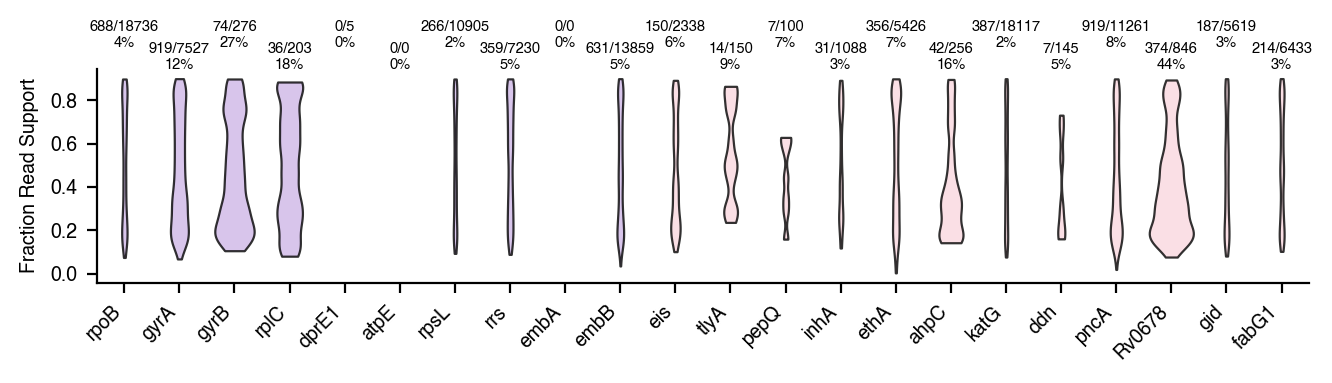

In [291]:
# Concatenate all mutations
all_mutations = pd.concat(combined_data)


x_axis_order = ["rpoB", "gyrA", "gyrB", "rplC", "dprE1", "atpE",  "rpsL", 'rrs', "embA", "embB","eis", "tlyA", "pepQ", "inhA", "ethA", "ahpC", "katG", "ddn", "pncA", "Rv0678", "gid", "fabG1"]

# Filter for FRS < 0.9 only
plot_data = all_mutations[all_mutations['FRS'] < 0.9].copy()

# === STEP 2: Compute scaling factors ===
total_counts = all_mutations.groupby('GENE').size()
shown_counts = plot_data.groupby('GENE').size()
scaling_factors = (shown_counts / total_counts).clip(upper=0.3).fillna(0).to_dict()

plot_data['GENE'] = pd.Categorical(plot_data['GENE'], categories=x_axis_order, ordered=True)


# Map categories for all genes in gene_list, defaulting to 'Non-Essential' (or whatever makes sense)
category_map = plot_data.set_index('GENE')['Category'].to_dict()
full_category_map = {gene: category_map.get(gene, 'Non-Essential') for gene in x_axis_order}

# Build full palette using that
palette = {
    gene: {'Essential': '#CFAFEF', 'Non-Essential': '#FFD1DC'}.get(category, '#FFFFFF')
    for gene, category in full_category_map.items()
}

# === STEP 3: Plot ===
fig, ax = plt.subplots(figsize=(6.69, 2))

violin = sns.violinplot(
    x="GENE",
    y="FRS",
    data=plot_data,
    inner=None,
    cut=0,
    bw=0.2,
    scale="area",
    order=x_axis_order,
    ax=ax,
    palette=palette)


ax.set_ylabel("Fraction Read Support", fontsize=7)
ax.set_xlabel("")
ax.tick_params(axis='both', labelsize=7)
sns.despine(ax=ax, top=True, right=True)

# === STEP 4: Scale violin widths ===
max_scale = max(scaling_factors.values())
category_positions = dict(zip(
    [t.get_text() for t in ax.get_xticklabels()],
    range(len(ax.get_xticklabels()))
))

# Scale violins
for artist in ax.findobj(match=PolyCollection):
    path = artist.get_paths()[0]
    verts = path.vertices
    x_mean = np.mean(verts[:, 0])
    closest_gene = min(category_positions, key=lambda g: abs(category_positions[g] - x_mean))
    scale = scaling_factors.get(closest_gene, 0) / max_scale
    verts[:, 0] = (verts[:, 0] - x_mean) * scale + x_mean
    artist.set_edgecolor("black")
    artist.set_linewidth(0.8)
    artist.set_alpha(0.8)

# === STEP 5: Annotate ===
for gene, i in category_positions.items():
    total = total_counts.get(gene, 0)
    plotted = shown_counts.get(gene, 0)
    frac = (plotted / total * 100) if total > 0 else 0

    # Compute violin area
    area = None
    for artist in ax.findobj(match=PolyCollection):
        path = artist.get_paths()[0]
        verts = path.vertices
        x_mean = np.mean(verts[:, 0])
        matched = min(category_positions, key=lambda g: abs(category_positions[g] - x_mean))
        if matched == gene:
            x = verts[:, 0]
            y = verts[:, 1]
            sort_idx = np.argsort(y)
            x_sorted = x[sort_idx]
            y_sorted = y[sort_idx]
            side_mask = x_sorted < x_mean
            area = np.trapezoid(x_sorted[side_mask] - x_mean, y_sorted[side_mask]) * 2
            break

    label = f"{plotted}/{total}\n{frac:.0f}%"
    print (f"{gene}: {plotted}/{total} = {frac:.2f}%")

    ax.text(
        i, 1.1 if i % 2 == 0 else 1.0,  # even indices slightly higher
        label,
        ha="center", va="center",
        fontsize=5.3
    )

plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### What proportion of resistance is conferred my minor alleles?

gryA and gyrB have very low numbers of minor alleles, and yet 

In [ ]:
genes = ["rpoB", "gyrA", "gyrB", "rplC", "dprE1", "atpE",  "rpsL", 'rrs', "embA", "embB", "eis", "tlyA", "pepQ", "inhA", "ethA", "ahpC", "katG", "ddn", "pncA", "Rv0678", "gid", "fabG1"]

mutations = functions.prep_mutations(
    'data/mutations-v3.3.0/',
    genes,
    version='v3.3.0',
    mut_path=cryptic_tables_path + 'MUTATIONS.parquet',
    var_path=cryptic_tables_path + 'VARIANTS.parquet',
    train=True
)
#mutations = mutations[~mutations.MUTATION.isin([v for d in drug_genes.values() for v in d['phylogenetic']])]
#catalogue = pd.read_csv('catalogues/catomatic_v3.3.0.csv')
#mutations = mutations[mutations.MUTATION.isin(catalogue[catalogue.PREDICTION=='R'].MUTATION.values)]
#mutations = mutations[~mutations.MUTATION.isin(phylogenetics.MUTATION.values)]

#mutations['GENE'] = mutations['MUTATION'].str.split('@').str[0]


In [282]:

mutations[(mutations.FRS<1)&(~mutations.MUTATION.isin(phylogenetics.MUTATION))].MUTATION.value_counts()

MUTATION
embB@R24P           5261
ahpC@V49G           1116
ahpC@V50G           1007
fabG1@c-60g          513
embB@A15P            407
                    ... 
ddn@G57D               1
katG@209_ins_aac       1
Rv0678@A102D           1
embB@D78G              1
rrs@g1519a             1
Name: count, Length: 3705, dtype: int64

In [143]:
mutations.MUTATION.value_counts()

MUTATION
gyrA@E21Q     53805
gyrA@G668D    49272
gyrA@S95T     49252
gyrA@A384V     4619
gyrA@G247S     3254
              ...  
gyrA@Y755C        1
gyrA@T339S        1
gyrA@T378I        1
gyrA@S506N        1
gyrA@G311A        1
Name: count, Length: 840, dtype: int64

In [128]:
mutations = functions.prep_mutations('data/mutations-v3.3.0/', 
                                        ['gyrA', 'gyrB'], 
                                        version='v3.3.0', 
                                        mut_path=cryptic_tables_path+'MUTATIONS.parquet', 
                                        var_path=cryptic_tables_path+'VARIANTS.parquet', 
                                        train=True)

In [129]:
mutations = mutations[mutations.MUTATION!='gyrA@S95T']

In [130]:
q = mutations[mutations.MUTATION=='gyrA@N193S'].UNIQUEID.values
w = mutations[(mutations.UNIQUEID.isin(q))]

In [131]:
w.MUTATION.value_counts()

MUTATION
gyrA@E21Q     132
gyrA@N193S    132
gyrA@c-34t    131
gyrA@A384V    131
gyrA@G668D    131
gyrB@M291I    130
gyrA@D94G      24
gyrA@A90V      18
gyrA@D94A      12
gyrA@D94Y       5
gyrB@E501D      3
gyrB@R446H      1
gyrB@A416V      1
Name: count, dtype: int64

In [132]:
mutations_singletons = w[w['UNIQUEID'].map(w['UNIQUEID'].value_counts()) > 1]
mutations_singletons

,UNIQUEID,MUTATION,FRS,IS_MINOR,MINOR_MUTATION,IS_NULL
1524,site.10.subj.SATRL0114477_S10.lab.TRL0114477_S...,gyrA@c-34t,1.0,False,NaN,False
1525,site.10.subj.SATRL0114477_S10.lab.TRL0114477_S...,gyrA@E21Q,1.0,False,NaN,False
1526,site.10.subj.SATRL0114477_S10.lab.TRL0114477_S...,gyrA@D94Y,1.0,False,NaN,False
1528,site.10.subj.SATRL0114477_S10.lab.TRL0114477_S...,gyrA@N193S,1.0,False,NaN,False
1529,site.10.subj.SATRL0114477_S10.lab.TRL0114477_S...,gyrA@A384V,1.0,False,NaN,False
...,...,...,...,...,...,...
202325,site.ENA.subj.SRR6982155.lab.1.iso.1,gyrA@E21Q,1.0,False,NaN,False
202327,site.ENA.subj.SRR6982155.lab.1.iso.1,gyrA@N193S,1.0,False,NaN,False
202328,site.ENA.subj.SRR6982155.lab.1.iso.1,gyrA@A384V,1.0,False,NaN,False
202330,site.ENA.subj.SRR6982155.lab.1.iso.1,gyrA@G668D,1.0,False,NaN,False


all samples with N193S have more than 1 variant...

phylo